# First Classification attempt - Remove some features

I'm going to use machine learning models to predict the injury status of the players with the data we have.
I do not expect to get good results, but I want to get a baseline to compare after improving the data and trying more advance techniques and models.

I'm going to use the following models:
- Logistic Regression
- Random Forest
- XGBoost
- Support Vector Machines

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb


import joblib
import os

import core.constants as c
from core.utils import extract_subject_id
from core.model_selection import (
    train_model_with_cv_eval,
    evaluate_models,
    save_models_and_results,
    load_models_and_results,
    plot_comparison_and_confusion,
    split_train_test_set
)


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
X = pd.read_csv(c.RICKD_BASELINE_X_FILE_V2, index_col=0)
Y = pd.read_csv(c.RICKD_BASELINE_Y_FILE_V2, index_col=0)

print(f"X Dataset shape: {X.shape}")
print(f"X Columns: {list(X.columns)}")
display(X.head())

print(f"Y Dataset shape: {Y.shape}")
print(f"Y Columns: {list(Y.columns)}")
display(Y.head())

# Class imbalance
print(f"Class distribution: {Y['is_injured'].value_counts()}")
print(f"Class distribution: {Y['is_injured'].value_counts(normalize=True)}")

X Dataset shape: (1832, 93)
X Columns: ['speed_r', 'age', 'Height', 'Weight', 'YrsRunning', 'NumRaces', 'l_step_width', 'l_stride_rate', 'l_stride_length', 'l_swing_time', 'l_stance_time', 'l_pelvis_peak_drop_angle', 'l_pelvis_drop_excursion', 'l_ankle_df_peak_angle', 'l_ankle_eve_peak_angle', 'l_ankle_eve_percent_stance', 'l_ankle_eve_excursion', 'l_ankle_rot_peak_angle', 'l_ankle_rot_excursion', 'l_knee_flex_peak_angle', 'l_knee_add_peak_angle', 'l_knee_add_excursion', 'l_knee_abd_peak_angle', 'l_knee_abd_excursion', 'l_knee_rot_peak_angle', 'l_knee_rot_excursion', 'l_hip_ext_peak_angle', 'l_hip_add_peak_angle', 'l_hip_add_excursion', 'l_hip_rot_peak_angle', 'l_hip_rot_excursion', 'l_foot_prog_angle', 'l_foot_ang_at_hs', 'l_mhw_exc_from_to', 'l_ankle_eve_peak_vel', 'l_ankle_rot_peak_vel', 'l_knee_abd_peak_vel', 'l_knee_add_peak_vel', 'l_hip_abd_peak_vel', 'l_knee_rot_peak_vel', 'l_hip_rot_peak_vel', 'l_pronation_onset', 'l_pronation_offset', 'l_peak_hip_add_velocity', 'l_peak_pelvic_

,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,-2.406926,1.232956,0.045388,-0.087876,0.370320,-0.124719,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-2.149309,0.0,0.0,0.0,0.0,0.0,0.0,1.0
100434_20101117T132240,-1.095016,1.068010,0.045388,-0.087876,1.214620,-0.124719,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.504414,1.0,0.0,0.0,0.0,0.0,0.0,1.0
100537_20120703T102550,-1.325076,-0.086615,0.072581,-0.200098,-0.956438,-0.124719,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.347673,1.0,0.0,0.0,0.0,1.0,0.0,1.0
100560_20120717T103748,-0.215279,-0.416508,0.746976,0.952054,-0.232752,-0.124719,0.677045,-1.610390,0.439240,-1.165155,...,3.526927,-1.746297,1.432837,1.0,0.0,0.0,0.0,1.0,0.0,1.0
101481_20120717T105021,-0.282875,-0.498981,0.420656,-0.873434,-0.232752,-0.124719,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.680932,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Y Dataset shape: (1832, 13)
Y Columns: ['injury_severity_code', 'injury_severity_value', 'injury_code', 'injury2_code', 'injury_desc', 'injury2_desc', 'injury_name', 'injury2_name', 'injured_joint_code', 'injured_joint2_code', 'injured_side_code', 'injured_side2_code', 'is_injured']


,injury_severity_code,injury_severity_value,injury_code,injury2_code,injury_desc,injury2_desc,injury_name,injury2_name,injured_joint_code,injured_joint2_code,injured_side_code,injured_side2_code,is_injured
id,,,,,,,,,,,,,
100433_20101005T132240,volume_intensity,2.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,knee,no_injury,right,right,1
100434_20101117T132240,volume_intensity,2.0,disc_dege,no_injury,Breakdown and gradual loss of spinal disc cush...,No injury has been diagnosed.,disc degeneration,no injury,lumbar_spine,no_injury,bilateral,right,1
100537_20120703T102550,missed_2_workouts,3.0,pain,no_injury,General sensation of discomfort without speci...,No injury has been diagnosed.,pain,no injury,hip_pelvis,no_injury,right,right,1
100560_20120717T103748,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,right,right,0
101481_20120717T105021,no_injury,0.0,no_injury,no_injury,No injury has been diagnosed.,No injury has been diagnosed.,no injury,no injury,no_injury,no_injury,no_injury,no_injury,0


Class distribution: is_injured
1    1167
0     665
Name: count, dtype: int64
Class distribution: is_injured
1    0.637009
0    0.362991
Name: proportion, dtype: float64


In [3]:
from core.utils import extract_subject_id

y = Y["is_injured"]
X_train, X_test, y_train, y_test = split_train_test_set(
    X, y, test_size=0.2, random_state=RANDOM_STATE, groups=extract_subject_id(X.index.to_series())
)

print(f"Train vs Test split: {X_train.shape[0] / X.shape[0] * 100:.2f}% / {X_test.shape[0] / X.shape[0] * 100:.2f}%")
print(f"Train Shape: {X_train.shape} / Test Shape: {X_test.shape}")
print(f"Injured class distribution Train: {y_train.value_counts().iloc[0] / y_train.shape[0] * 100:.2f}%")
print(f"Injured class distribution Test: {y_test.value_counts().iloc[0] / y_test.shape[0] * 100:.2f}%")

Train vs Test split: 79.15% / 20.85%
Train Shape: (1450, 93) / Test Shape: (382, 93)
Injured class distribution Train: 64.48%
Injured class distribution Test: 60.73%


In [4]:
# # Save train and test sets to disk for reproducibility
# X_train.to_csv(c.RICKD_BASELINE_X_TRAIN_FILE_V2)
# X_test.to_csv(c.RICKD_BASELINE_X_TEST_FILE_V2)
# y_train.to_csv(c.RICKD_BASELINE_Y_TRAIN_FILE_V2)
# y_test.to_csv(c.RICKD_BASELINE_Y_TEST_FILE_V2)

In [5]:
# Load train and test sets from disk
X_train = pd.read_csv(c.RICKD_BASELINE_X_TRAIN_FILE_V2, index_col=0)
X_test = pd.read_csv(c.RICKD_BASELINE_X_TEST_FILE_V2, index_col=0)
y_train = pd.read_csv(c.RICKD_BASELINE_Y_TRAIN_FILE_V2, index_col=0).squeeze()
y_test = pd.read_csv(c.RICKD_BASELINE_Y_TEST_FILE_V2, index_col=0).squeeze()

X_train.head()

,speed_r,age,Height,Weight,YrsRunning,NumRaces,l_step_width,l_stride_rate,l_stride_length,l_swing_time,...,r_peak_hip_add_velocity,r_peak_pelvic_drop_velocity,r_vertical_oscillation,Gender_female,Gender_male,DominantLeg_ambidextrous,DominantLeg_left,DominantLeg_right,Level_competitive,Level_recreational
id,,,,,,,,,,,,,,,,,,,,,
100433_20101005T132240,-2.406926,1.232956,0.045388,-0.087876,0.370320,-0.124719,-0.307243,0.000986,-2.622528,-0.338913,...,-1.743700,0.239058,-2.149309,0.0,0.0,0.0,0.0,0.0,0.0,1.0
100434_20101117T132240,-1.095016,1.068010,0.045388,-0.087876,1.214620,-0.124719,-1.831460,0.886585,-1.458975,-0.466027,...,0.764244,-0.390267,-1.504414,1.0,0.0,0.0,0.0,0.0,0.0,1.0
100537_20120703T102550,-1.325076,-0.086615,0.072581,-0.200098,-0.956438,-0.124719,-0.037324,-0.643565,-1.241474,-0.084685,...,2.255015,0.604189,-0.347673,1.0,0.0,0.0,0.0,1.0,0.0,1.0
101481_20120717T105021,-0.282875,-0.498981,0.420656,-0.873434,-0.232752,-0.124719,0.104643,-0.746010,-0.016982,-0.148242,...,0.475554,1.000454,0.680932,1.0,0.0,0.0,0.0,0.0,0.0,0.0
100595_20120829T125604,-1.122921,0.985537,-1.939725,-0.432025,2.420764,-0.124719,-0.521567,-0.643565,-1.012029,0.805114,...,-0.157913,-0.460219,-0.201375,1.0,0.0,0.0,0.0,1.0,0.0,1.0


In [ ]:
selected_cols = [
    # "speed_r",
    "age",
    "Height",
    "Weight",
    #"YrsRunning",
    #"NumRaces",
    "l_step_width",
    "l_stride_rate",
    "l_stride_length",
    "l_swing_time",
    "l_stance_time",
    "l_pelvis_peak_drop_angle",
    "l_pelvis_drop_excursion",
    "l_ankle_df_peak_angle",
    "l_ankle_eve_peak_angle",
    "l_ankle_eve_percent_stance",
    "l_ankle_eve_excursion",
    "l_ankle_rot_peak_angle",
    "l_ankle_rot_excursion",
    "l_knee_flex_peak_angle",
    "l_knee_add_peak_angle",
    "l_knee_add_excursion",
    "l_knee_abd_peak_angle",
    "l_knee_abd_excursion",
    "l_knee_rot_peak_angle",
    "l_knee_rot_excursion",
    "l_hip_ext_peak_angle",
    "l_hip_add_peak_angle",
    "l_hip_add_excursion",
    "l_hip_rot_peak_angle",
    "l_hip_rot_excursion",
    "l_foot_prog_angle",
    "l_foot_ang_at_hs",
    "l_mhw_exc_from_to",
    "l_ankle_eve_peak_vel",
    "l_ankle_rot_peak_vel",
    "l_knee_abd_peak_vel",
    "l_knee_add_peak_vel",
    "l_hip_abd_peak_vel",
    "l_knee_rot_peak_vel",
    "l_hip_rot_peak_vel",
    "l_pronation_onset",
    "l_pronation_offset",
    "l_peak_hip_add_velocity",
    "l_peak_pelvic_drop_velocity",
    "l_vertical_oscillation",
    "r_step_width",
    "r_stride_rate",
    "r_stride_length",
    "r_swing_time",
    "r_stance_time",
    "r_pelvis_peak_drop_angle",
    "r_pelvis_drop_excursion",
    "r_ankle_df_peak_angle",
    "r_ankle_eve_peak_angle",
    "r_ankle_eve_percent_stance",
    "r_ankle_eve_excursion",
    "r_ankle_rot_peak_angle",
    "r_ankle_rot_excursion",
    "r_knee_flex_peak_angle",
    "r_knee_add_peak_angle",
    "r_knee_add_excursion",
    "r_knee_abd_peak_angle",
    "r_knee_abd_excursion",
    "r_knee_rot_peak_angle",
    "r_knee_rot_excursion",
    "r_hip_ext_peak_angle",
    "r_hip_add_peak_angle",
    "r_hip_add_excursion",
    "r_hip_rot_peak_angle",
    "r_hip_rot_excursion",
    "r_foot_prog_angle",
    "r_foot_ang_at_hs",
    "r_mhw_exc_from_to",
    "r_ankle_eve_peak_vel",
    "r_ankle_rot_peak_vel",
    "r_knee_abd_peak_vel",
    "r_knee_add_peak_vel",
    "r_hip_abd_peak_vel",
    "r_knee_rot_peak_vel",
    "r_hip_rot_peak_vel",
    "r_pronation_onset",
    "r_pronation_offset",
    "r_peak_hip_add_velocity",
    "r_peak_pelvic_drop_velocity",
    "r_vertical_oscillation",
    # "Gender_female",
    # "Gender_male",
    # "DominantLeg_ambidextrous",
    # "DominantLeg_left",
    # "DominantLeg_right",
    # "Level_competitive",
    # "Level_recreational",
]
X_train = X_train[selected_cols]
X_test = X_test[selected_cols]

## Model configuration

In [7]:
models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('classifier', LogisticRegression(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10, 100],
            'classifier__penalty': ['l1', 'l2'],
            'classifier__solver': ['liblinear']
        }
    },
    
    'Random Forest': {
        'pipeline': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 10, 20, 30],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    
    'XGBoost': {
        'pipeline': Pipeline([
            ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))
        ]),
        'param_grid': {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [3, 6, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.2],
            'classifier__subsample': [0.8, 0.9, 1.0]
        }
    },
    
    'SVM': {
        'pipeline': Pipeline([
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'param_grid': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto', 0.1, 0.01]
        }
    }
}


## Train Models with Grid Search

In [8]:
# Train stratified by groups
trained_models = train_model_with_cv_eval(
    X_train=X_train,
    y_train=y_train,
    groups=extract_subject_id(X_train.index),
    models_config=models_config,
    scoring='roc_auc',
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

# Evaluate
results = evaluate_models(trained_models, X_test=X_test, y_test=y_test)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Fitting 5 folds for each of 81 candidates, totalling 405 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fitting 5 folds for each of 24 candidates, totalling 120 fits


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/adrianzapaterreig/Documents/Per

In [9]:
# Persist using utilities
results_model = save_models_and_results(
    trained_models=trained_models,
    eval_results=results,
    target_folder=c.RICKD_BASELINE_RESULTS_FOLDER_V4,
    results_summary_file=c.RICKD_BASELINE_RESULTS_SUMMARY_V4,
)
print(f"Results summary saved to: {c.RICKD_BASELINE_RESULTS_SUMMARY_V4}")

Results summary saved to: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/baselineV4_missing_values/results_summary.json


### Checkpoint: Load results and models

In [10]:
# Load using utilities
results, trained_models = load_models_and_results(
    results_summary_file=c.RICKD_BASELINE_RESULTS_SUMMARY_V4
)

## Analysis of Models

Model Performance Comparison by Test ROC AUC:
                 Model  Test ROC AUC  Test Accuracy  Test Precision  \
1        Random Forest        0.7136         0.7120          0.7309   
0  Logistic Regression        0.6968         0.6990          0.6930   
3                  SVM        0.6957         0.6675          0.6672   
2              XGBoost        0.6925         0.6937          0.6884   

   Test Recall  Test F1-Score  Test Best CV Score  
1       0.7120         0.6809              0.6940  
0       0.6990         0.6881              0.6749  
3       0.6675         0.6673              0.7168  
2       0.6937         0.6784              0.6944  

Best performing model: Random Forest
Best Test ROC AUC Score: 0.7136


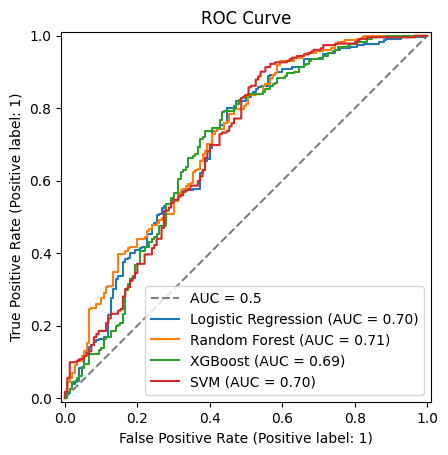

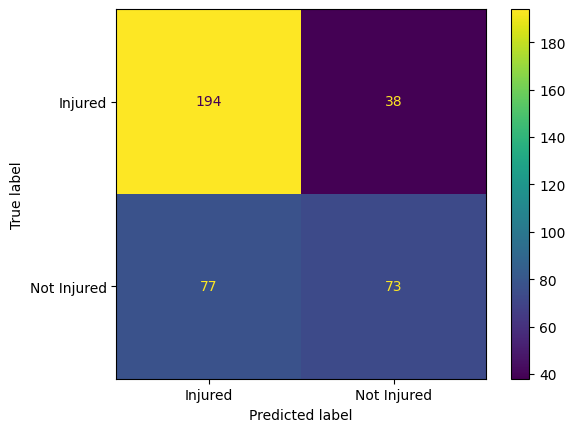

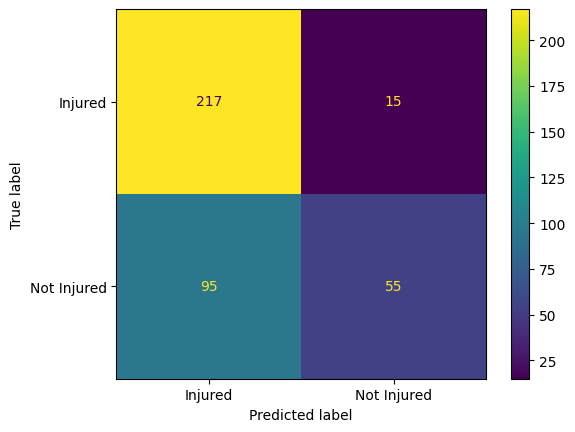

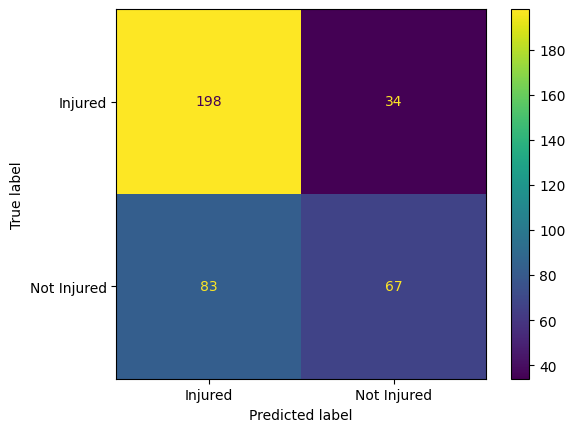

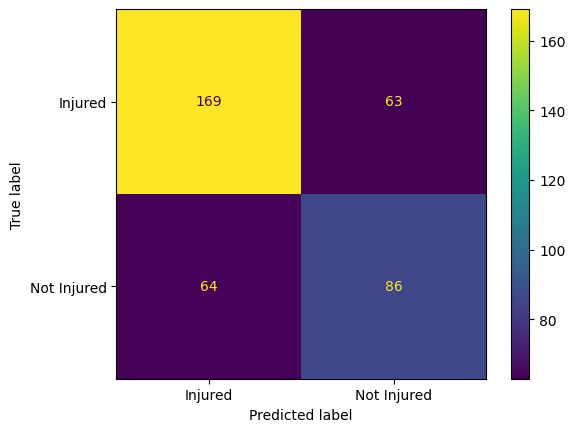

In [11]:
comparison_df = plot_comparison_and_confusion(
    results=results,
    y_test=y_test,
    class_labels=['Injured', 'Not Injured'],
    label_order=[1, 0],
)

PRIMARY_METRIC = 'Test ROC AUC'
print(f"Model Performance Comparison by {PRIMARY_METRIC}:")
print('='*50)
print(comparison_df.round(4))

best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest performing model: {best_model_name}")
print(f"Best {PRIMARY_METRIC} Score: {comparison_df.iloc[0][PRIMARY_METRIC]:.4f}")